# Evaluation of test year GCM-driven run

In [ ]:
import valenspy as vp
from valenspy._utilities import load_yml
from valenspy.processing.select import select_point
from valenspy.diagnostic.functions import mean_bias, mean_absolute_error, root_mean_square_error, spearman_correlation, perkins_skill_score, time_series_spatial_mean
from valenspy.diagnostic.visualizations import plot_time_series, plot_map
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd


#from eval_gcm_functions import *

from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [6]:


# define machine name - used for paths of (observational) datasets
machine = 'hortense'

manager = vp.InputManager(machine=machine)

Processing dataset: ERA5
Processing dataset: ERA5-Land


ValueError: unconverted data remains when parsing with format "%Y": "_09", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

## 0. Pre-defining 

In [ ]:
# Define datasets
gcm = 'EC-Earth'
domain = 'BEL28'
model = "CCLM"
experiment_type = "test"
experiment = f"test_experiments/CB2_{model}_{domain}_{gcm}_{experiment_type}"

experiment_era5 = f"CB2_{model}_{domain}_ERA5_evaluation_ECSG"

figdir = "/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/fiens/CCLM_test_eval_figures/"
# figdir_exp = figdir + f"{experiment}/"
# Path(figdir_exp).mkdir(parents=True, exist_ok=True)

## 0.1 Tailored valenspy functions

In [ ]:
def visualize_eval_exp_diff_thesis(da_eval, da_exp, da_diff, variable = None, statistic = "mean",region=None, flag_show = True):
    """
    Visualizes the absolute minima, absolute maxima, and scaled experimental dataset on 3 maps.

    Parameters:
    -----------
    da_abs_minima : xr.DataArray
        The DataArray containing the absolute minima.
    da_abs_maxima : xr.DataArray
        The DataArray containing the absolute maxima.
    scaled_exp : xr.DataArray
        The DataArray containing the scaled experimental data.
    """
    cm = 1/2.54
    # Create the figure and axes
    fig, axes = plt.subplots(2, 2, figsize=(16*cm, 9*cm),subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    #plt.suptitle(da_eval.long_name + " [" + da_eval.units + "]")
    
    if 'tas' in variable:
        da_eval = da_eval - 273.15
        da_exp = da_exp - 273.15
        var_units = "°C"
    elif 'T_2M' in variable:
        da_eval = da_eval - 273.15
        da_exp = da_exp - 273.15
        variable = "tas"
        var_units = "°C"
    else:
        var_units = da_eval.units


    # Calculate global min and max
    # Ensure min and max values are calculated correctly
    vmin = da_eval.min().values
    vmax = da_eval.max().values
    
    vmin_bias = da_diff.min().values
    vmax_bias = da_diff.max().values

    if np.abs(vmin_bias) > vmax_bias:
        vmax_bias = np.abs(vmin_bias)
    elif np.abs(vmin_bias) <= vmax_bias:
        vmin_bias = -1*vmax_bias

    if statistic == 'mean':
        title_diff = "Exp - Eval"
    if statistic == 'min':
        title_diff = "Exp - Eval"
    if statistic == 'max':
        title_diff = "Exp - Eval"

    # Plot 1: Absolute minima
    #print("Plotting Evaluation")
    p1 = da_eval.plot(ax=axes[0], add_colorbar=False, cmap='viridis', vmin=vmin, vmax=vmax, x = "lon", y = "lat")
    axes[0].set_title("Evaluation (" + statistic + ")")
    # cbar1 = fig.colorbar(p1, ax=axes[0], orientation='vertical', shrink=0.3)
    # cbar1.set_label(variable + " [" + var_units + "]")

    # Plot 3: Absolute maxima
    #print("Plotting Experiment")
    p2 = da_exp.plot(ax=axes[1], add_colorbar=False, cmap='viridis', vmin=vmin, vmax=vmax, x = "lon", y = "lat")
    axes[1].set_title("Experiment (" + statistic + ")")
    # cbar2 = fig.colorbar(p2, ax=axes[1], orientation='vertical', shrink=0.3)
    # cbar2.set_label(variable + " [" + var_units + "]")

    # Plot 2: Scaled experimental data
    #print("Plotting Bias")


    p3 = da_diff.plot(ax=axes[3], add_colorbar=False, cmap='RdBu_r', vmin=vmin_bias, vmax=vmax_bias,x = "lon", y = "lat")
    axes[3].set_title(title_diff)


    fig.subplots_adjust(right=0.86)
    cbar_ax = fig.add_axes([0.94, 0.55, 0.02, 0.35])
    cbar = fig.colorbar(p1, cax=cbar_ax)
    cbar.set_label(variable + " [" + var_units + "]")

    cbar_ax = fig.add_axes([0.94, 0.1, 0.02, 0.35])
    cbar = fig.colorbar(p3, cax=cbar_ax)
    cbar.set_label(f'Bias of {variable} [{var_units}]')

    
    borders = cfeature.BORDERS.with_scale('50m')
    coastline = cfeature.COASTLINE.with_scale('50m')
    for ax in axes:
        ax.add_feature(borders, linestyle=":")
        ax.add_feature(coastline, linewidth=0.5, color="k")
        if region == "europe":
            ax.set_ylim([15, 80])
            ax.set_xlim([-50, 70])
        elif region == "belgium":
            ax.set_ylim([45, 55])
            ax.set_xlim([-5, 15])

    axes[2].set_visible(False)


    return fig, axes

In [ ]:
def calc_plot_bias_map_eval(variable: str, da_eval, da_exp, months_to_analyse: list, region='europe', statistic ='mean',flag_save=False, flag_show=True, **kwargs): 

    if statistic == 'mean':
        da_eval = da_eval.mean(dim = "year")
        da_diff = da_exp - da_eval
    if statistic == 'min':
        da_eval = da_eval.min(dim = "year")
        da_diff = da_exp - da_eval
    if statistic == 'max':
        da_eval = da_eval.max(dim = "year")
        da_diff = da_exp - da_eval
    
    #print("everything fine")
    fig, axes = visualize_eval_exp_diff_thesis(da_eval = da_eval,  da_exp = da_exp,  da_diff = da_diff, statistic = statistic, variable = variable, region=region, flag_show = flag_show)

    return fig, axes

In [ ]:
def get_spaghetti_GLUE_thesis(da_eval: xr.DataArray, da_exp: xr.DataArray, variable: str): 

    """
    Plots the yearly cycle for each year in the evaluation dataset (`da_eval`)
    and the experimental dataset (`da_exp`), starting on January 1st for all.

    Parameters:
        da_eval (xarray.Dataset): Evaluation dataset with multiple years.
        da_exp (xarray.Dataset): Experimental dataset with a single year.
        variable (str): The name of the variable to plot.

    Returns:
        None: Displays the plot.
    """
    cm = 1/2.54
    fig, ax = plt.subplots(figsize = (20*cm,6*cm))
    
    # Exctract unique years
    # years_eval = np.unique(pd.to_datetime(da_eval.time).year)
    # years_exp = np.unique(pd.to_datetime(da_exp.time).year)

    time = da_exp.time

    if 'tas' in variable:
        da_eval = da_eval - 273.15
        da_exp = da_exp - 273.15
        var_units = "°C"
    elif 'T_2M' in variable:
        da_eval = da_eval - 273.15
        da_exp = da_exp - 273.15
        var_units = "°C"
        variable = "tas"
    else:
        var_units = da_eval.units

    if hasattr(time, "dt"):
        years_exp = np.unique(time.dt.year.values)
    else:
        years_exp = np.unique(time.values)

    time = da_eval.time

    if hasattr(time, "dt"):
        years_eval = np.unique(time.dt.year.values)
    else:
        years_eval = np.unique(time.values)

    # # Loop over all years:
    for yr in years_eval:
        ds_year = da_eval.sel(time=da_eval.time.dt.year.isin([yr]))
        #print("In year " + str(yr) + ' we have ' + str(len(ds_year["time"])) + " datapoints.")
        if isinstance(ds_year, xr.Dataset):
            da_year = ds_year[variable]
        else:
            da_year = ds_year
        df_year = da_year
        da_year["doy"] = da_year['time'].dt.dayofyear

        ax.plot(da_year['doy'], da_year, color = "grey", linewidth = 0.8)

    for yr in years_exp:
        ds_year = da_exp.sel(time=da_exp.time.dt.year.isin([yr]))
        #print("In year " + str(yr) + ' we have ' + str(len(ds_year["time"])) + " datapoints.")
        if isinstance(ds_year, xr.Dataset):
            da_year = ds_year[variable]
        else:
            da_year = ds_year
        df_year = da_year
        da_year["doy"] = da_year['time'].dt.dayofyear

        ax.plot(da_year['doy'], da_year, label="Experimental Dataset" , color = "red", linewidth = 0.8)

    # Customize Plot
    #ax.set_title(f"Yearly Cycle of " + da_eval.long_name)
    ax.set_xlabel("Day of Year")
    ax.set_ylabel(variable + " [" + var_units + "]")
    #plt.ylim([270,300])
    custom_lines = [Line2D([0], [0], color="grey"),Line2D([0], [0], color="red"),
        ]

    ax.legend(custom_lines, ["Evaluation", "Experimental"], loc="best", ncol=1)
    ax.grid()


    return fig, ax

In [ ]:
borders = cfeature.BORDERS.with_scale('50m')
coastline = cfeature.COASTLINE.with_scale('50m')

In [ ]:
experiment

'test_experiments/CB2_CCLM_BEL28_EC-Earth_test'

In [ ]:
# include_vars = ["T_2M", "QV_2M"]
# statistics = ["mean", "min", "mean"]

# for variable in include_vars:
#     daily_statistic = "mean"
#     da_exp  = load_gcm_experiment(experiment,variable,daily_statistic)
#     da_eval = load_era5_experiment(experiment_era5,variable,daily_statistic)

#     da_mean_exp, da_mean_eval, da_exp_yearly_avg, da_eval_yearly_avg = preprocess_experiments(da_exp, da_eval)

#     fig, ax = get_spaghetti_GLUE_thesis(da_mean_eval, da_mean_exp, variable)
#     fig.savefig(figdir + f"{gcm}_{domain}_{variable}_GLUE.png", dpi = 350, bbox_inches="tight")

#     for statistic in statistics: 

#         fig, axes = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='europe', statistic = statistic,flag_show = True)
#         fig.savefig(figdir + f"{gcm}_{domain}_{variable}_{statistic}_spatial.png", dpi = 350, bbox_inches="tight")

## 1. BEL28


### Temperature 2m

In [ ]:
variable = "T_2M"
daily_statistic = "mean"
da_exp  = load_gcm_experiment(experiment,variable,daily_statistic)
da_eval = load_era5_experiment(experiment_era5,variable,daily_statistic)

da_mean_exp, da_mean_eval, da_exp_yearly_avg, da_eval_yearly_avg = preprocess_experiments(da_exp, da_eval)


/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/CB2_CCLM_BEL28_EC-Earth_test/T_2M/daily/T_2M_daily_mean_1995.nc
['/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/T_2M/daily/T_2M_daily_mean_1982.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/T_2M/daily/T_2M_daily_mean_1983.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/T_2M/daily/T_2M_daily_mean_1984.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/T_2M/daily/T_2M_daily_mean_1985.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/T_2M/daily/T_2M_daily_mean_1986.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/C

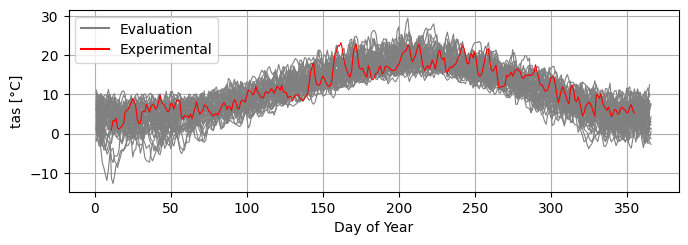

In [ ]:
# create figures
fig, ax = get_spaghetti_GLUE_thesis(da_mean_eval, da_mean_exp, variable)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_GLUE.png", dpi = 350, bbox_inches="tight")
plt.show()

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/CORDEXbeII/software/conda_envs/valenspy_shared/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


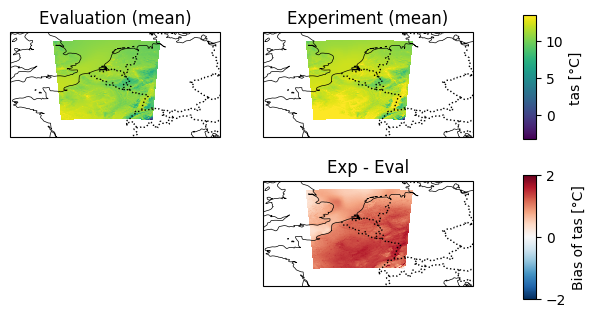

In [ ]:
fig, axes = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "mean",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_mean_spatial.png", dpi = 350, bbox_inches="tight")

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/CORDEXbeII/software/conda_envs/valenspy_shared/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


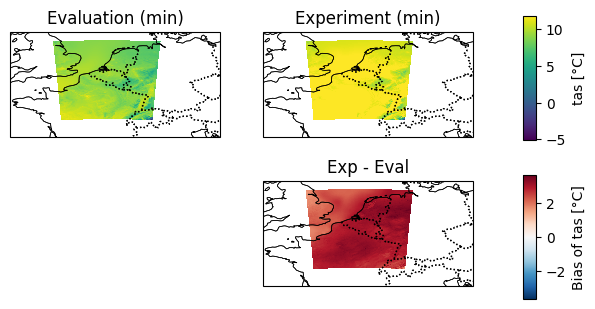

In [ ]:
fig, axes = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "min",flag_show = True)
for ax in axes:
    ax.add_feature(borders, linestyle=":")
    ax.add_feature(coastline, linewidth=0.5, color="k")
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_min_spatial.png", dpi = 350, bbox_inches="tight")

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/CORDEXbeII/software/conda_envs/valenspy_shared/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


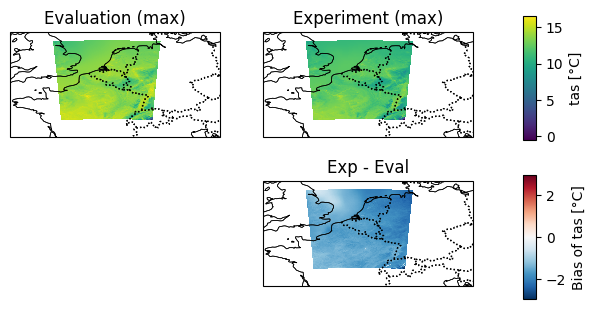

In [ ]:
fig, axes = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "max",flag_show = True)
for ax in axes:
    ax.add_feature(borders, linestyle=":")
    ax.add_feature(coastline, linewidth=0.5, color="k")
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_max_spatial.png", dpi = 350, bbox_inches="tight")

### Total precipitation

In [ ]:
variable = "TOT_PREC"
daily_statistic = "sum"

# load and preprocess experiments

da_exp  = load_gcm_experiment(experiment,variable,daily_statistic)
da_eval = load_era5_experiment(experiment_era5,variable,daily_statistic)

da_mean_exp, da_mean_eval, da_exp_yearly_avg, da_eval_yearly_avg = preprocess_experiments(da_exp, da_eval)


/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/CB2_CCLM_BEL28_EC-Earth_test/TOT_PREC/daily/TOT_PREC_daily_sum_1995.nc


['/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/TOT_PREC/daily/TOT_PREC_daily_sum_1982.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/TOT_PREC/daily/TOT_PREC_daily_sum_1983.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/TOT_PREC/daily/TOT_PREC_daily_sum_1984.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/TOT_PREC/daily/TOT_PREC_daily_sum_1985.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/TOT_PREC/daily/TOT_PREC_daily_sum_1986.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_BEL28_ERA5_evaluation_ECSG/TOT_PREC/daily/TOT_PREC_daily_sum_1987.nc', '/dodrio/scratch/projects/2022_200/project_ou

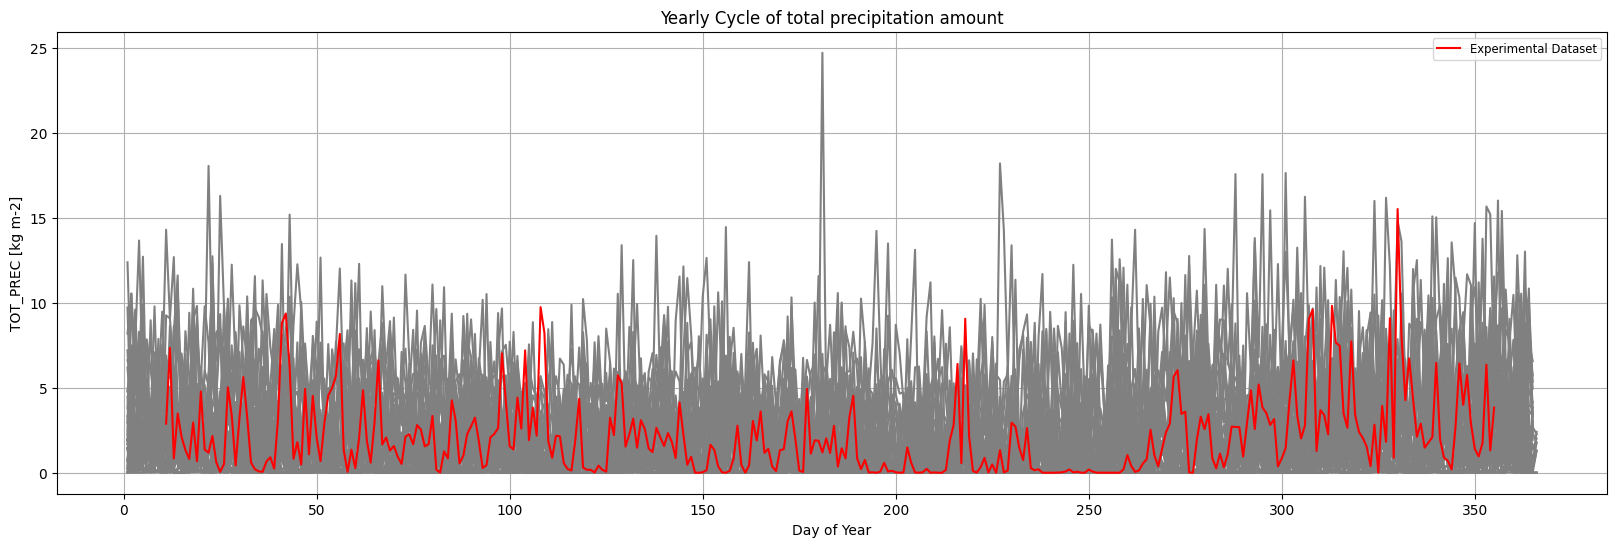

In [ ]:

# create figures
fig, ax = get_spaghetti_GLUE(da_mean_eval, da_mean_exp, variable)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_GLUE.png", dpi = 350, bbox_inches="tight")

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/CORDEXbeII/software/conda_envs/valenspy_shared/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


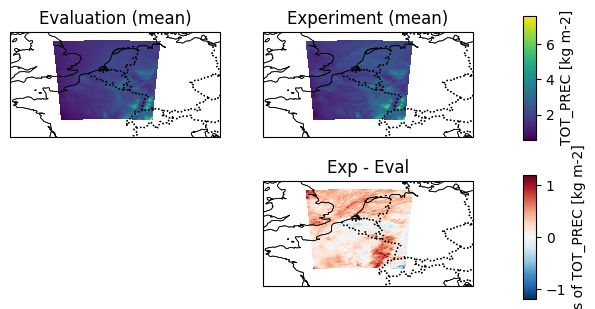

In [ ]:
fig, axes  = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "mean",flag_show = True)
for ax in axes:
    ax.add_feature(borders, linestyle=":")
    ax.add_feature(coastline, linewidth=0.5, color="k")
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_mean_spatial.png", dpi = 350, bbox_inches="tight")

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/CORDEXbeII/software/conda_envs/valenspy_shared/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


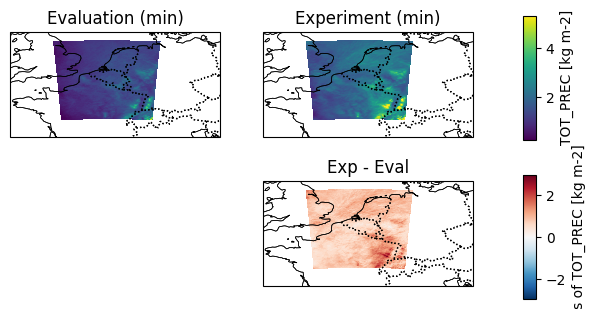

In [ ]:
fig, axes  = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "min",flag_show = True)
for ax in axes:
    ax.add_feature(borders, linestyle=":")
    ax.add_feature(coastline, linewidth=0.5, color="k")
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_min_spatial.png", dpi = 350, bbox_inches="tight")

/dodrio/scratch/projects/2022_200/project_output/RMIB-UGent/CORDEXbeII/software/conda_envs/valenspy_shared/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


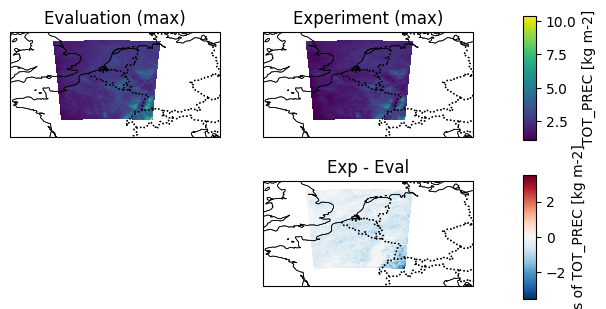

In [ ]:
fig, axes  = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "max",flag_show = True)
for ax in axes:
    ax.add_feature(borders, linestyle=":")
    ax.add_feature(coastline, linewidth=0.5, color="k")
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_max_spatial.png", dpi = 350, bbox_inches="tight")

### RELHUM_2M

In [ ]:
variable = "RELHUM_2M"
daily_statistic = "mean"

# load and preprocess experiments

da_exp  = load_gcm_experiment(experiment,variable,daily_statistic)
da_eval = load_era5_experiment(experiment_era5,variable,daily_statistic)

da_mean_exp, da_mean_eval, da_exp_yearly_avg, da_eval_yearly_avg = preprocess_experiments(da_exp, da_eval)


/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/CB2_CCLM_BEL28_EC-Earth_test/RELHUM_2M/daily/RELHUM_2M_daily_mean_1995.nc


OSError: no files to open

In [ ]:

# create figures
fig, ax = get_spaghetti_GLUE_thesis(da_mean_eval, da_mean_exp, variable)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_GLUE.png", dpi = 350, bbox_inches="tight")

In [ ]:
fig, ax = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "mean",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_mean_spatial.png", dpi = 350, bbox_inches="tight")


In [ ]:
fig, ax = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "min",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_min_spatial.png", dpi = 350, bbox_inches="tight")

In [ ]:
fig, ax = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='belgium', statistic = "max",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_max_spatial.png", dpi = 350, bbox_inches="tight")

### Shortwave Radiation

/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_EUR11_MIROC6_test/ASODIFD_S/daily/ASODIFD_S_daily_mean_1995.nc
['/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_EUR11_ERA5_evaluation/ASODIFD_S/daily/ASODIFD_S_daily_mean_1979.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_EUR11_ERA5_evaluation/ASODIFD_S/daily/ASODIFD_S_daily_mean_1980.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_EUR11_ERA5_evaluation/ASODIFD_S/daily/ASODIFD_S_daily_mean_1981.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_EUR11_ERA5_evaluation/ASODIFD_S/daily/ASODIFD_S_daily_mean_1982.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/CB2_CCLM_EUR11_ERA5_evaluation/ASODIFD_S/daily/ASODIFD_S_daily_mean_1983.nc', '/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/

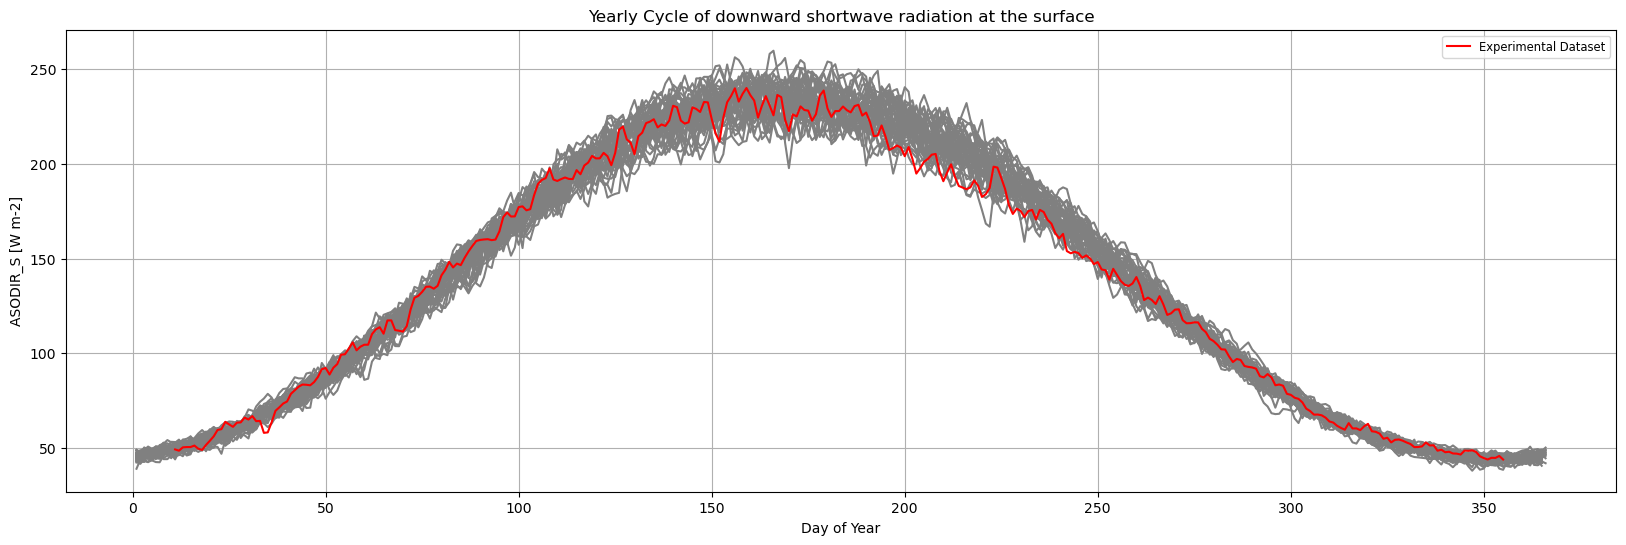

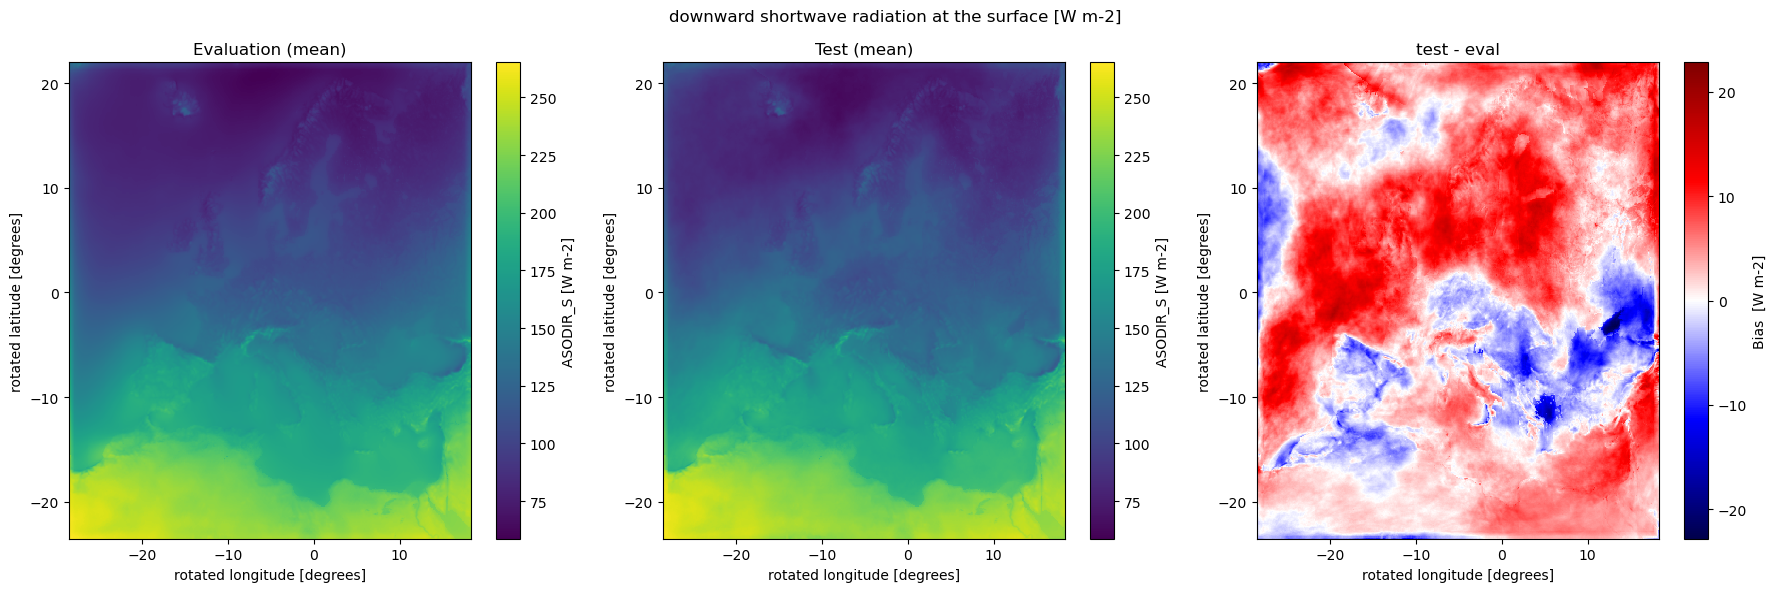

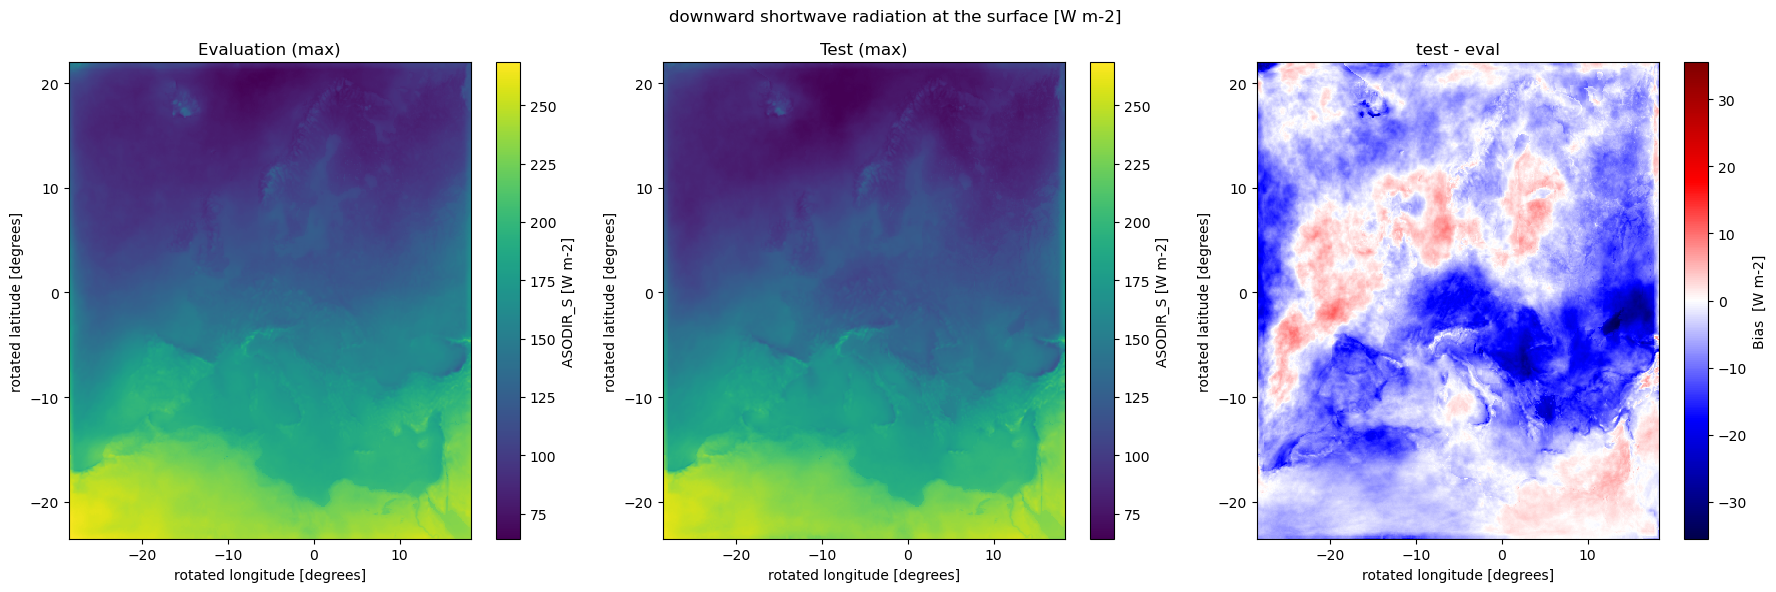

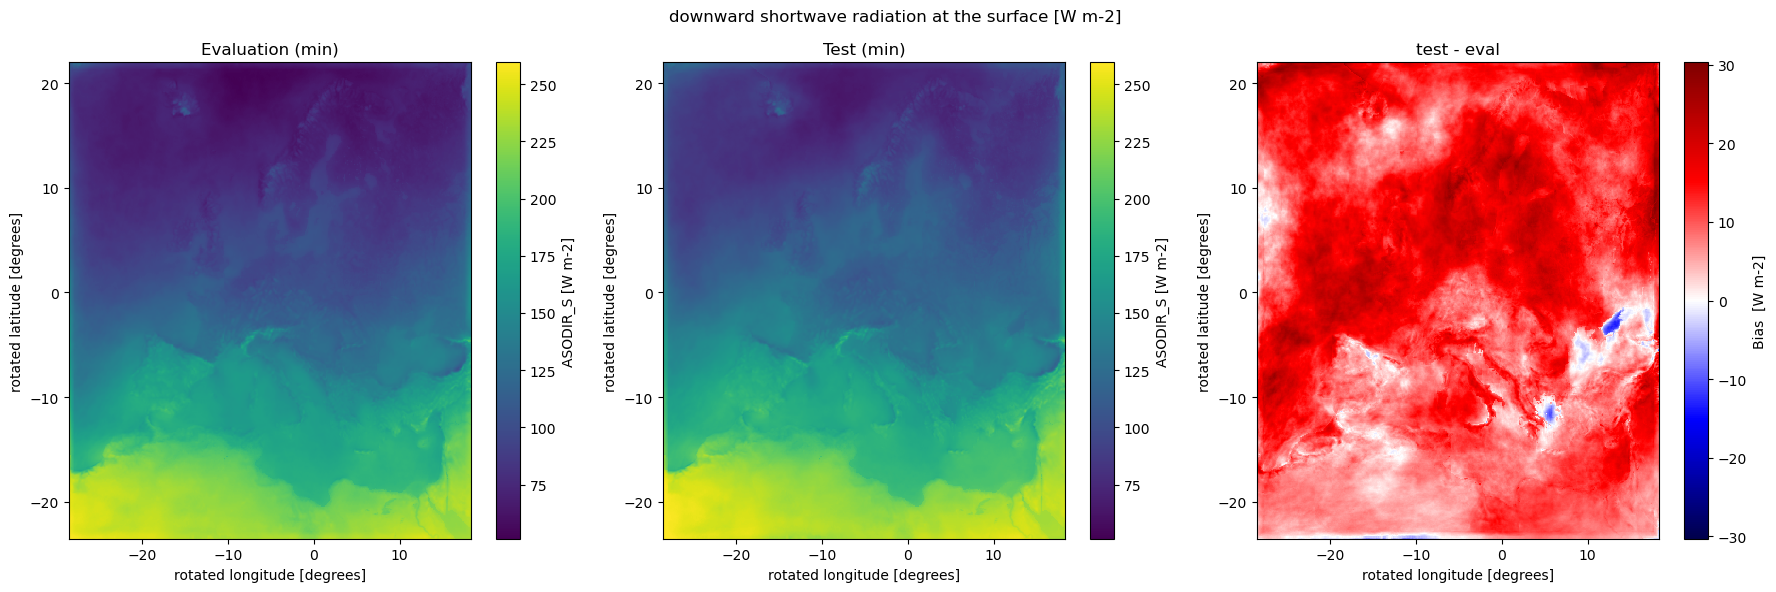

In [ ]:
variable = "ASODIFD_S"
daily_statistic = "mean"

da_exp_diffuse  = load_gcm_experiment(experiment,variable,daily_statistic)
da_eval_diffuse = load_era5_experiment(experiment_era5,variable, daily_statistic)


variable = "ASODIR_S"
da_exp_direct  = load_gcm_experiment(experiment,variable,daily_statistic)
da_eval_direct = load_era5_experiment(experiment_era5,variable, daily_statistic)

da_eval = da_eval_direct + da_eval_diffuse
da_exp = da_exp_direct + da_exp_diffuse

da_eval.attrs['standard_name'] = 'downwelling_shortwave_radiation'
da_eval.attrs['long_name'] = 'downward shortwave radiation at the surface'

# load and preprocess experiments
da_mean_exp, da_mean_eval, da_exp_yearly_avg, da_eval_yearly_avg = preprocess_experiments(da_exp, da_eval)
variabel = "rsds"


In [ ]:
# create figures
fig, ax = get_spaghetti_GLUE(da_mean_eval, da_mean_exp, variable)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_GLUE.png", dpi = 350, bbox_inches="tight")

In [ ]:
fig, ax = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='europe', statistic = "mean",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_mean_spatial.png", dpi = 350, bbox_inches="tight")

In [ ]:
fig, ax = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='europe', statistic = "min",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_min_spatial.png", dpi = 350, bbox_inches="tight")

In [ ]:
fig, ax = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='europe', statistic = "max",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_max_spatial.png", dpi = 350, bbox_inches="tight")

### PMSL

In [ ]:
variable = "PMSL"
daily_statistic = "mean"

# load and preprocess experiments
da_exp  = load_gcm_experiment(experiment,variable,daily_statistic)
da_eval = load_era5_experiment(experiment_era5,variable,daily_statistic)

da_mean_exp, da_mean_eval, da_exp_yearly_avg, da_eval_yearly_avg = preprocess_experiments(da_exp, da_eval)


/dodrio/scratch/projects/2022_200/project_output/rcs/CORDEXBE2/postprocessing/test_experiments/CB2_CCLM_EUR11_EC-Earth_test/PMSL/daily/PMSL_daily_mean_1995.nc


OSError: no files to open

In [ ]:

# create figures
fig, ax = get_spaghetti_GLUE(da_mean_eval, da_mean_exp, variable)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_GLUE.png", dpi = 350, bbox_inches="tight")

In [ ]:
fig, axes = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='europe', statistic = "mean",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_min_spatial.png", dpi = 350, bbox_inches="tight")

In [ ]:
fig, axes = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='europe', statistic = "min",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_min_spatial.png", dpi = 350, bbox_inches="tight")

In [ ]:
fig, axes = calc_plot_bias_map_eval(variable, da_eval_yearly_avg, da_exp_yearly_avg, months_to_analyse = [1,2,3,4,5,6,7,8,9,10,11,12], region='europe', statistic = "max",flag_show = True)
fig.savefig(figdir + f"{gcm}_{domain}_{variable}_max_spatial.png", dpi = 350, bbox_inches="tight")